# Task_5_ Sales Prediction Using Python
Sales prediction means predicting how much of a product people will buy based on factors such as the amount spent on advertising across TV, Radio, and Newspaper platforms.
I will use the **Advertising dataset** and build a **Linear Regression** model to predict Sales.

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully')

All libraries imported successfully


## 2. Load dataset

In [3]:
df = pd.read_csv('Advertising.csv', index_col=0)
print('Dataset shape: ',df.shape)
df.head(10)

Dataset shape:  (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print('=== Dataset info: ===')
df.info()

=== Dataset info: ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
# Statistical summary
print('=== Statistical Summary: ===')
df.describe()

=== Statistical Summary: ===


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
# Missing values
print('=== Missing Values: ===')
print(df.isnull().sum().sum())

=== Missing Values: ===
0


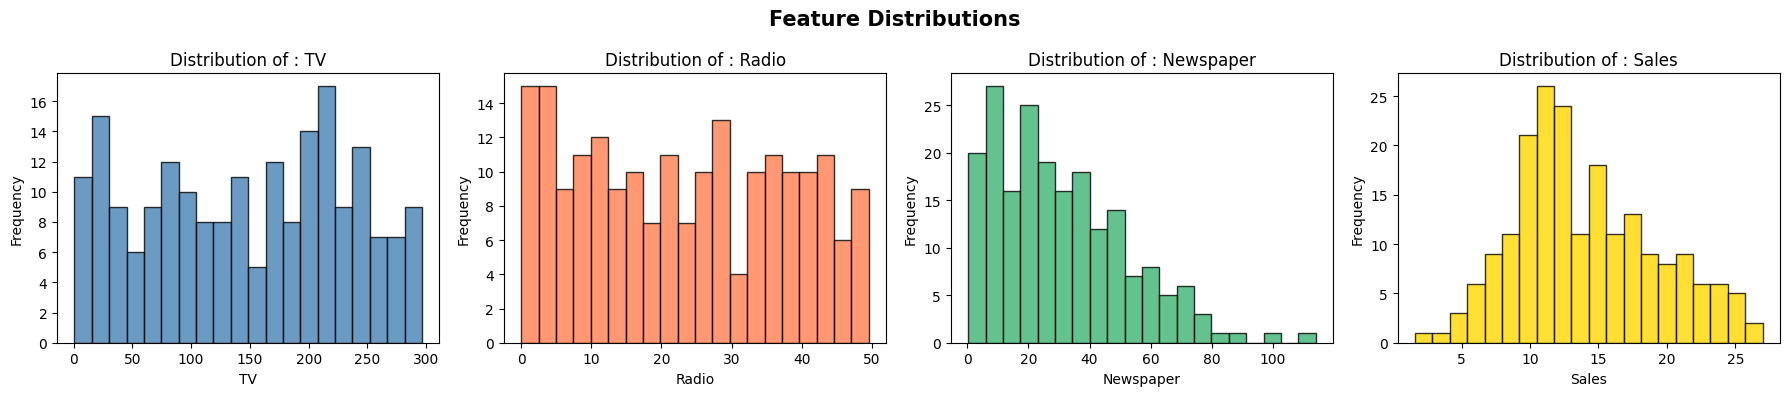

In [7]:
# Distribution of each feature
fig, axes = plt.subplots(1,4,figsize=(18,4))
cols=['TV','Radio','Newspaper','Sales']
colors=['steelblue','coral','mediumseagreen','gold']

for ax, col, colo in zip(axes,cols,colors):
    ax.hist(df[col],color=colo, bins=20, edgecolor='black', alpha=0.8)
    ax.set_title(f'Distribution of : {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

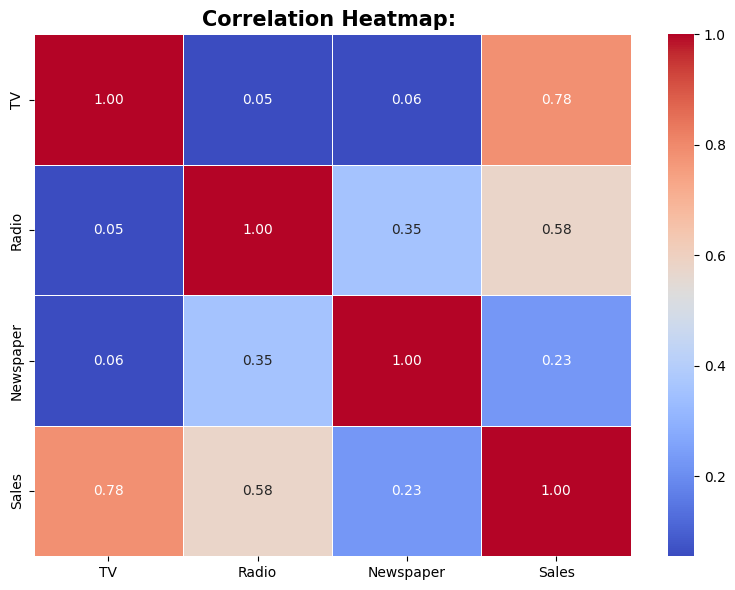

In [8]:
# Correlation Heatmap:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidth=0.5)
plt.title('Correlation Heatmap: ',fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

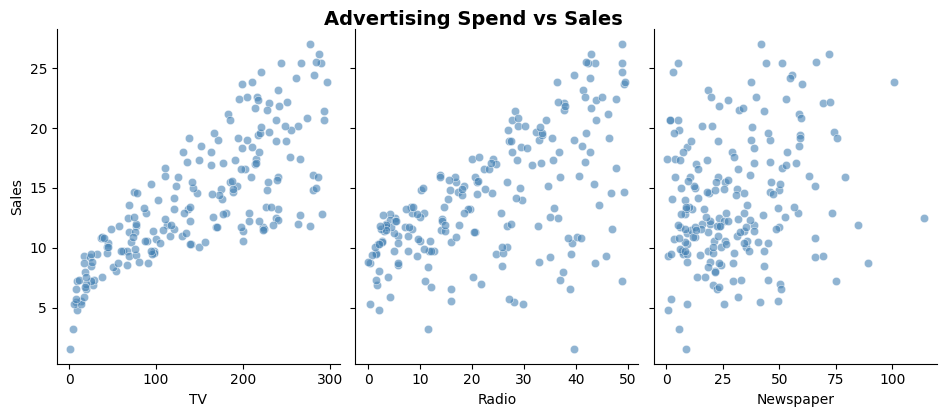

In [9]:
# Pairplot to see relationships
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales',
             height=4, aspect=0.8, kind='scatter', plot_kws={'alpha': 0.6, 'color': 'steelblue'})
plt.suptitle('Advertising Spend vs Sales', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Feature election & Data Splitting

In [10]:
# Define feature (X) and target (Y)
X = df[['TV','Radio','Newspaper']]
y= df['Sales']

print('Features Shape: ',X.shape)
print('Target Shape: ',y.shape)

Features Shape:  (200, 3)
Target Shape:  (200,)


In [11]:
# Split to train, test
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42 
)

print(f'Training Samples: {X_train.shape[0]}')
print(f'Testing Samples: {X_test.shape[0]}')

Training Samples: 160
Testing Samples: 40


## 5. Build & Train Linear Regression Model 

In [14]:
model=LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully')
print(f'Intercepts: {model.intercept_:.4f}')
print('\nCoefficients')
for feat, coef in zip(X.columns, model.coef_):
    print(f'{feat:12s}: {coef:.4f}')

Model trained successfully
Intercepts: 2.9791

Coefficients
TV          : 0.0447
Radio       : 0.1892
Newspaper   : 0.0028


## 6 Model Evaluation

In [15]:
y_pred=model.predict(X_test)

mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)

print('Model Evaluation Metrics: ')
print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'Root Mean Squared Error: {rmse:.4f}')
print(f'R2 score: {r2:.4f}')
print(f'\nModel explains {r2*100:.2f}% of the variance in Sales.')

Model Evaluation Metrics: 
Mean Absolute Error: 1.4608
Mean Squared Error: 3.1741
Root Mean Squared Error: 1.7816
R2 score: 0.8994

Model explains 89.94% of the variance in Sales.


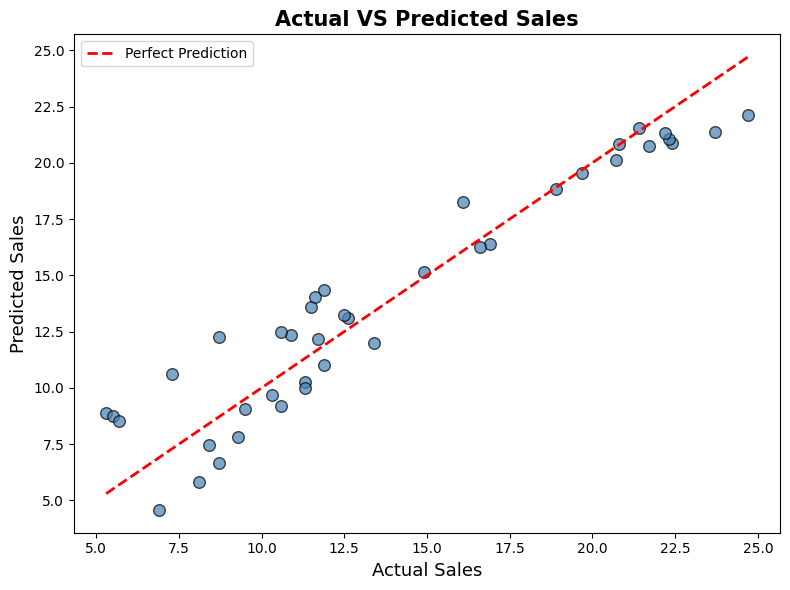

In [16]:
#Actual vs Predicted Score
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='steelblue', edgecolors='black', alpha=0.7, s=70)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction'
        )
plt.xlabel('Actual Sales',fontsize=13)
plt.ylabel('Predicted Sales', fontsize=13)
plt.title('Actual VS Predicted Sales', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

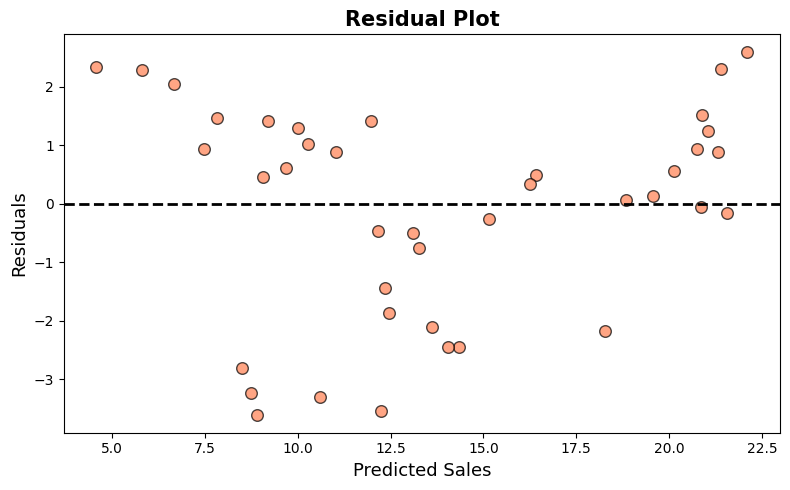

In [17]:
# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, color='coral', edgecolors='black', alpha=0.7, s=70)
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.xlabel('Predicted Sales', fontsize=13)
plt.ylabel('Residuals', fontsize=13)
plt.title('Residual Plot', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

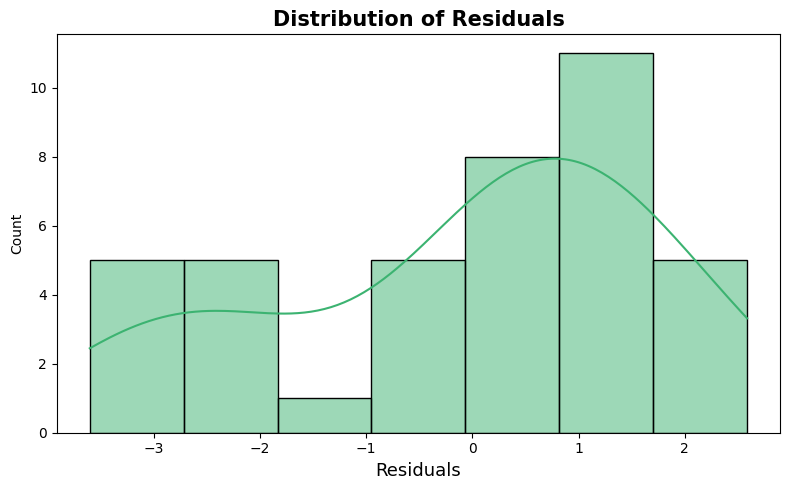

In [18]:
# Distribution of Residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='mediumseagreen', edgecolor='black')
plt.xlabel('Residuals', fontsize=13)
plt.title('Distribution of Residuals', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance

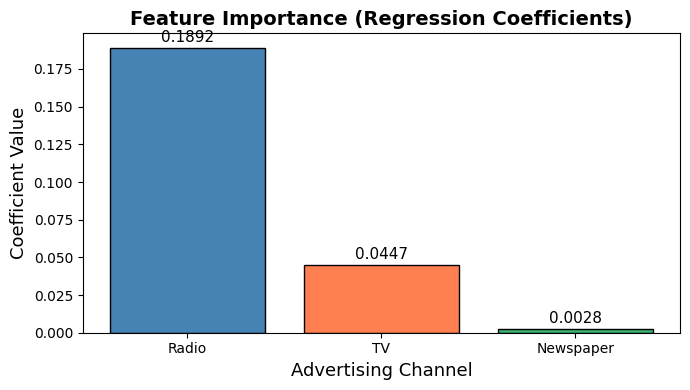

In [19]:
# Bar chart of coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(7, 4))
bars = plt.bar(coef_df['Feature'], coef_df['Coefficient'],
               color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='black')
plt.xlabel('Advertising Channel', fontsize=13)
plt.ylabel('Coefficient Value', fontsize=13)
plt.title('Feature Importance (Regression Coefficients)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, coef_df['Coefficient']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Predict Sales on new data

In [20]:
new_data=pd.DataFrame({
    'TV':[230.1, 44.5, 100.0],
    'Radio':[37.8, 39.9, 20.0],
    'Newspaper':[69.2, 45.1, 10.0]
})
predictions=model.predict(new_data)
new_data['Predicted_Sales']=predictions
print('Predictions for new data: ')
new_data

Predictions for new data: 


,TV,Radio,Newspaper,Predicted_Sales
0,230.1,37.8,69.2,20.613971
1,44.5,39.9,45.1,12.642940
2,100.0,20.0,10.0,11.263531


## Summary

| Metric | Value |
|--------|-------|
| Algorithm | Multiple Linear Regression |
| Features Used | TV, Radio, Newspaper |
| Train/Test Split | 80% / 20% |
| R² Score | ~0.90 |
| Key Finding | TV and Radio have the highest impact on Sales |

**Conclusion:** The Linear Regression model achieves a high R² score (~0.90), meaning it explains ~90% of the variance in sales. TV advertising has the highest positive impact on sales, followed by Radio. Newspaper has minimal impact.